### Downstream analysis KAIJU, module: metal_indexes_rb
Raw reads count are aggregated for all the samples using the geomosaic command:
```bash
geomosaic gather -s gmsetup -p rmi_rpi_indexes
```

plot of the variation in the Redox Metabolic Index (A) and the Metal Plasticity Index (B) against temperature for a series of metagenomes obtained using the read-based analysis stream.

In [1]:
library(ggplot2)
library(ggrepel)

options(readr.show_col_types = FALSE)

SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (3480027614.py, line 4)

In [ ]:
theme_glab <- function(base_size = 11, base_family = "") {
  theme_bw(base_size = base_size, base_family = base_family) %+replace%
    theme(
      legend.background = element_blank(),
      legend.title      = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65),
        hjust = 0
      ),
      legend.text       = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      legend.key.size   = unit(0.8, "lines"),
      plot.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        hjust = 0.5, 
        face = "bold"
      ),
      axis.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      axis.text         = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      panel.grid.major  = element_blank(),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(
        fill = NA,
        colour = rgb(100, 100, 100, maxColorValue = 255)
      ),
      complete = TRUE
    )
}

In [ ]:
env <- as.data.frame(read_delim("./cr18_env_geomosaicPlot.csv", 
                  delim = ",",
                  skip = 1, 
                  locale = locale(decimal_mark = ",")))

rownames(env) <- env$Geomosaic_sample


In [ ]:
taxa <- as.data.frame(read_delim("./tables/ko_carbon_metab.csv",
                    delim = ',',  # Note: read.delim uses 'sep', read_delim uses 'delim'
                    locale = locale(decimal_mark = ",")
                    ))

rownames(taxa) <- taxa$ko

In [ ]:
# Generating Phyloseq Object
phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa_df)),
  sample_data(env)
)

In [ ]:

plot_scatter <- function(df) {
  x_var <- df$rmi
  y_var <- df$rpi
  
  ggplot(df, aes(x = .data[[x_var]], y = .data[[y_var]], label = rownames(df))) +
    geom_point(size = 3, color = "steelblue") +
    geom_text_repel(size = 3) +
    labs(
      x = x_var,
      y = y_var,
      title = paste("Scatterplot:", x_var, "vs", y_var),
    ) +
    theme_glab()
}

In [ ]:

plot_scatter <- function(df) {
  x_var <- colnames(df)[2]
  y_var <- colnames(df)[3]
  
  ggplot(df, aes(x = .data[[x_var]], y = .data[[y_var]], label = rownames(df))) +
    geom_point(size = 3, color = "steelblue") +
    geom_text_repel(size = 3) +
    labs(
      x = x_var,
      y = y_var,
      title = paste("Scatterplot:", x_var, "vs", y_var),
    ) +
    theme_glab()
}

In [ ]:
df$group <- gsub(".*_(S|F)$", "\\1", rownames(df))

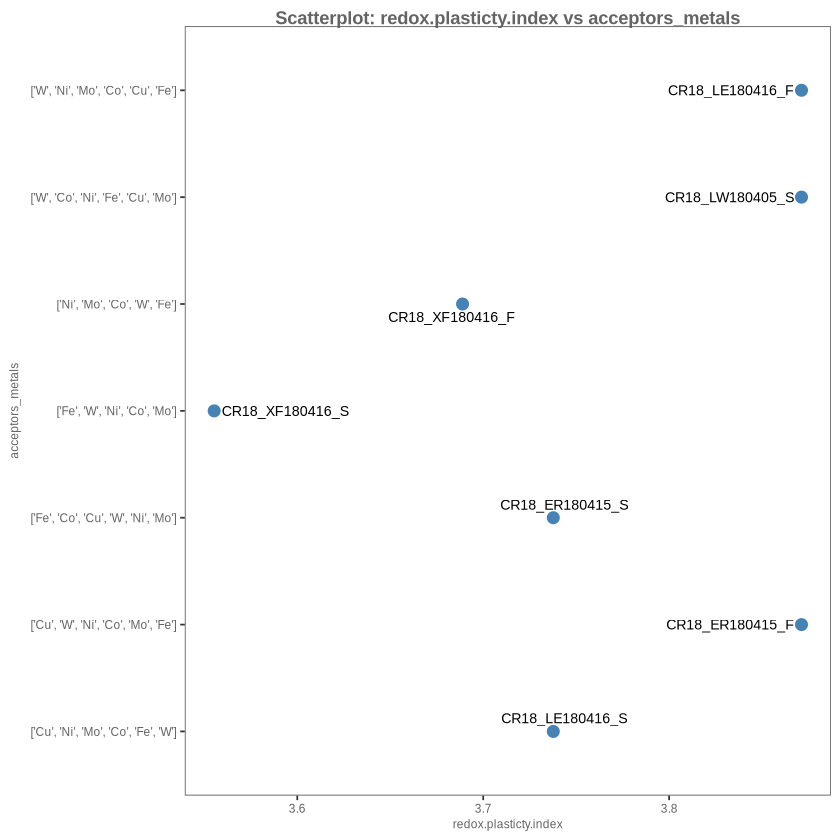

In [ ]:
df <- read.delim("../tables/metal_indexes_rb/metal_indexes.tsv", row.names = 1)
plot_scatter(df)